# Minggu 1

## 4.1 A. Audit Kualitas Data

### 1. Baca CSV dengan timestamp sebagai tipe tanggal-waktu. Laporkan jumlah baris, jumlah kolom, periode pengamatan, jumlah kolam, dan interval pencatatan.

In [17]:
import pandas as pd

df = pd.read_csv(
    "../data/smart_aqua_synthetic_water_quality.csv",
    parse_dates=["timestamp"]
)

df = df.sort_values(
    ["pond_id","timestamp"]
).reset_index(drop=True)

print("Shape: ", df.shape)
print("Periode:", df["timestamp"].min(), "sampai", df["timestamp"].max())
print("Jumlah kolam:", df["pond_id"].nunique())
print("Kolam:", sorted(df["pond_id"].unique()))

Shape:  (23040, 26)
Periode: 2026-01-05 00:00:00 sampai 2026-03-05 23:30:00
Jumlah kolam: 8
Kolam: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08']


### 2. Periksa keunikan record_id dan kombinasi pond_id–timestamp. Periksa apakah urutan waktu setiap kolam lengkap dan konsisten.

In [18]:
# cari keunikan record by record_id
print("Total record : ", len(df))
print("record_id unik : ", df["record_id"].unique())

# cari keunikan kombinasi pond_id + timestamp
pond_timestamp_unique = df[["pond_id","timestamp"]].drop_duplicates().shape[0]

print("Kombinasi pond_id + timestamp unik : ", pond_timestamp_unique)

# cek duplikasi
print("\n Duplikasi record_id : ", df["record_id"].duplicated().sum())
print("Duplikasi pond_id - timestamp : ", df.duplicated(["pond_id","timestamp"]).sum())

Total record :  23040
record_id unik :  <StringArray>
['AQUA-000001', 'AQUA-000002', 'AQUA-000003', 'AQUA-000004', 'AQUA-000005',
 'AQUA-000006', 'AQUA-000007', 'AQUA-000008', 'AQUA-000009', 'AQUA-000010',
 ...
 'AQUA-023031', 'AQUA-023032', 'AQUA-023033', 'AQUA-023034', 'AQUA-023035',
 'AQUA-023036', 'AQUA-023037', 'AQUA-023038', 'AQUA-023039', 'AQUA-023040']
Length: 23040, dtype: str
Kombinasi pond_id + timestamp unik :  23040

 Duplikasi record_id :  0
Duplikasi pond_id - timestamp :  0


tidak ditemukan record_id yang duplikat dan kombinasi pond_id + timestamp yang duplikat

#### Cek kelengkapan interval waku

perlu dipastikan bahwa untuk setiap kolam, timestamp berjalan dengan normal (00:00 sampai 23.30). gaada tiba2 01:00 sampai 03:00

In [19]:
for pond, group in df.groupby("pond_id"):
  ts = group["timestamp"].sort_values()

  interval = ts.diff().dropna()

  print(f"\n{pond}")
  print("Jumlah observasi : ", len(group))
  print("Awal : ", ts.min())
  print("Akhir : ", ts.max())
  print("Interval : " )
  print(interval.value_counts())


P01
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P02
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P03
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P04
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P05
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P06
Jumlah observasi :  2880
Awal :  2026-01-05 00:00:00
Akhir :  2026-03-05 23:30:00
Interval : 
timestamp
0 days 00:30:00    2879
Name: count, dtype: int64

P07
Jumlah observasi :  2880
Awal :  2026-01-

Kesimpulan dari sini, Dataset terdiri atas 23.040 observasi dan 26 variabel yang merepresentasikan delapan kolan selama 60 hari pengamatan. Setiap kolam memiliki 2.88- observasi dengan interval pencatatan 30 menit. Pemeriksaan menunjukan bahwa seluruh record_id bersifat unik dan tidak ditemukan duplikasi pada kombinasi pond_id dan timestamp. Urutan waktu pada masing2 kolam juga konsisten dengan interval 30 menit tanpa ditemukan jeda pencatatan.

### 3. Buat tabel tipe data, jumlah nilai hilang, persentase nilai hilang, jumlah nilai unik, minimum, dan maksimum untuk setiap variabel.

In [20]:
audit = pd.DataFrame({
    "variable" : df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing": df.isna().sum().values,
    "missing_pct":(df.isna().mean() * 100).values,
    "unique": df.nunique(dropna=True).values,
    "min": [
        df[c].min() if pd.api.types.is_numeric_dtype(df[c]) else None
        for c in df.columns
    ],
    "max": [
        df[c].max() if pd.api.types.is_numeric_dtype(df[c]) else None
        for c in df.columns
    ]
})

audit

,variable,dtype,missing,missing_pct,unique,min,max
0,record_id,str,0,0.000000,23040,NaN,NaN
1,timestamp,datetime64[us],0,0.000000,2880,NaN,NaN
2,pond_id,str,0,0.000000,8,NaN,NaN
3,day_of_cycle,int64,0,0.000000,60,1.000,60.000
4,hour_decimal,float64,0,0.000000,48,0.000,23.500
5,time_period,str,0,0.000000,4,NaN,NaN
6,species,str,0,0.000000,1,NaN,NaN
7,pond_volume_m3,int64,0,0.000000,7,45.000,54.000
8,stocking_density_kg_m3,float64,0,0.000000,424,15.770,39.260
9,biomass_kg,float64,0,0.000000,438,820.000,1845.400


ben penak diwaca

In [21]:
audit["missing_pct"] = audit["missing_pct"].round(2)

audit

,variable,dtype,missing,missing_pct,unique,min,max
0,record_id,str,0,0.00,23040,NaN,NaN
1,timestamp,datetime64[us],0,0.00,2880,NaN,NaN
2,pond_id,str,0,0.00,8,NaN,NaN
3,day_of_cycle,int64,0,0.00,60,1.000,60.000
4,hour_decimal,float64,0,0.00,48,0.000,23.500
5,time_period,str,0,0.00,4,NaN,NaN
6,species,str,0,0.00,1,NaN,NaN
7,pond_volume_m3,int64,0,0.00,7,45.000,54.000
8,stocking_density_kg_m3,float64,0,0.00,424,15.770,39.260
9,biomass_kg,float64,0,0.00,438,820.000,1845.400


### 4. Ringkas frekuensi setiap nilai sensor_quality_flag. Temukan contoh spike, flatline, drift, dan missing value pada grafik waktu.

In [22]:
flag_summary = (
    df["sensor_quality_flag"]
    .value_counts()
    .rename_axis("sensor_quality_flag")
    .reset_index(name="count")
)

flag_summary["percentage"] = (
    flag_summary["count"] / len(df) * 100
).round(2)

flag_summary

,sensor_quality_flag,count,percentage
0,OK,22356,97.03
1,PH_DRIFT,327,1.42
2,SENSOR_MISSING,147,0.64
3,DO_FLATLINE,145,0.63
4,DO_SPIKE,61,0.26
5,MULTIPLE,4,0.02


Mencari misssing value


In [23]:
sensor_cols = [
    "temperature_c",
    "ph",
    "dissolved_oxygen_mg_l",
    "ammonia_mg_l",
    "nitrite_mg_l",
    "turbidity_ntu"
]

missing_by_flag = pd.crosstab(
    df["sensor_quality_flag"],
    df[sensor_cols].isna().any(axis=1)
)

missing_by_flag

col_0,False,True
sensor_quality_flag,,
DO_FLATLINE,145,0
DO_SPIKE,61,0
MULTIPLE,2,2
OK,22356,0
PH_DRIFT,327,0
SENSOR_MISSING,0,147


Nilai spike

In [24]:
df.loc[
    df["sensor_quality_flag"] == "DO_SPIKE",
    [
        "timestamp",
        "pond_id",
        "dissolved_oxygen_mg_l",
        "sensor_quality_flag"
    ]
].head(10)

,timestamp,pond_id,dissolved_oxygen_mg_l,sensor_quality_flag
1255,2026-01-31 03:30:00,P01,-0.93,DO_SPIKE
1744,2026-02-10 08:00:00,P01,12.69,DO_SPIKE
1921,2026-02-14 00:30:00,P01,13.85,DO_SPIKE
2049,2026-02-16 16:30:00,P01,-0.73,DO_SPIKE
2187,2026-02-19 13:30:00,P01,-0.67,DO_SPIKE
2345,2026-02-22 20:30:00,P01,11.71,DO_SPIKE
2371,2026-02-23 09:30:00,P01,-0.25,DO_SPIKE
3199,2026-01-11 15:30:00,P02,13.22,DO_SPIKE
3733,2026-01-22 18:30:00,P02,12.59,DO_SPIKE
4965,2026-02-17 10:30:00,P02,-0.87,DO_SPIKE


Flatline

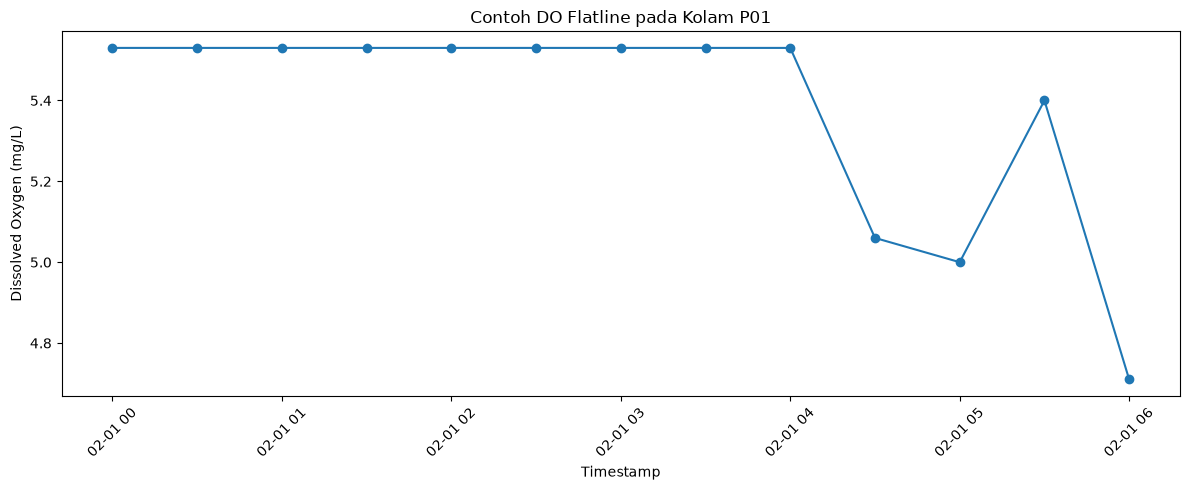

In [25]:
pond = "P01"

plot_df = df[
    (df["pond_id"] == pond) &
    (df["timestamp"].between(
        "2026-02-01 00:00",
        "2026-02-01 06:00"
    ))
]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["timestamp"],
    plot_df["dissolved_oxygen_mg_l"],
    marker="o"
)

plt.xlabel("Timestamp")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.title("Contoh DO Flatline pada Kolam P01")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

drift

In [26]:
ph_drift = df[df["sensor_quality_flag"] == "PH_DRIFT"]

ph_drift.groupby("pond_id").size()

pond_id
P01     42
P02     53
P04     51
P05    115
P06     34
P08     32
dtype: int64

## B. Descriptive Analytics: Apa yang Terjadi?

### 1. Hitung mean, median, simpangan baku, minimum, maksimum, kuartil, IQR, dan koefisien variasi untuk seluruh parameter kualitas air. Jelaskan mengapa koefisien variasi tidak selalu tepat ketika mean mendekati nol.

In [27]:
water_quality = [
    "temperature_c",
    "ph",
    "dissolved_oxygen_mg_l",
    "ammonia_mg_l",
    "nitrite_mg_l",
    "turbidity_ntu"
]

descriptive_stats = []

for col in water_quality:
    s = df[col].dropna()

    mean = s.mean()
    std = s.std()

    descriptive_stats.append({
        "Parameter": col,
        "Mean": mean,
        "Median": s.median(),
        "Std": std,
        "Min": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "Max": s.max(),
        "IQR": s.quantile(0.75) - s.quantile(0.25),
        "CV (%)": (std / mean * 100) if mean != 0 else np.nan
    })

descriptive_stats = pd.DataFrame(descriptive_stats)

descriptive_stats.round(3)

,Parameter,Mean,Median,Std,Min,Q1,Q3,Max,IQR,CV (%)
0,temperature_c,28.601,28.600,1.240,25.840,27.530,29.670,31.650,2.140,4.335
1,ph,7.353,7.350,0.182,6.920,7.210,7.490,8.400,0.280,2.470
2,dissolved_oxygen_mg_l,5.206,5.160,0.886,-0.990,4.630,5.760,15.880,1.130,17.018
3,ammonia_mg_l,0.336,0.333,0.088,0.110,0.273,0.398,0.593,0.125,26.014
4,nitrite_mg_l,0.281,0.274,0.079,0.103,0.217,0.337,0.527,0.120,28.279
5,turbidity_ntu,49.340,48.700,7.814,26.100,43.600,54.600,80.700,11.000,15.837


### 2. Bandingkan statistik kualitas air menurut:
- kolam;
- time_period;
- jam pengamatan; dan
- fase awal, tengah, dan akhir siklus budidaya.

In [28]:
pond_quality = (
    df.groupby("pond_id")[water_quality]
    .mean()
    .round(3)
)

pond_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
pond_id,,,,,,
P01,28.138,7.353,5.447,0.248,0.202,42.065
P02,28.439,7.356,5.310,0.315,0.258,47.387
P03,28.639,7.344,5.043,0.388,0.327,54.412
P04,28.541,7.355,5.151,0.342,0.285,49.468
P05,29.139,7.371,5.222,0.337,0.278,49.167
P06,28.738,7.350,4.905,0.425,0.362,56.941
P07,28.336,7.345,5.453,0.267,0.221,43.842
P08,28.840,7.353,5.115,0.368,0.311,51.400


Kolam

<Figure size 1200x600 with 0 Axes>

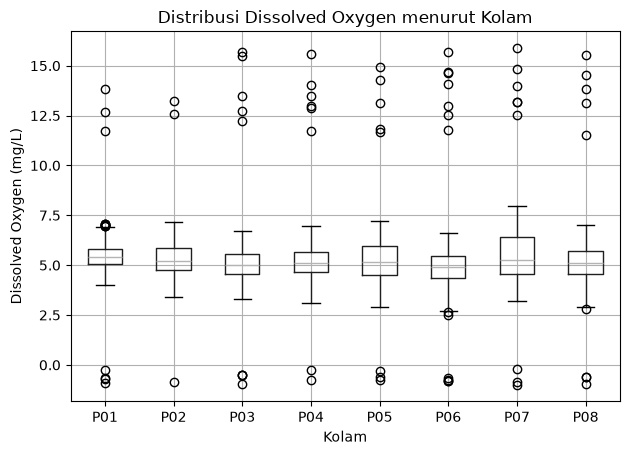

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df.boxplot(
    column="dissolved_oxygen_mg_l",
    by="pond_id"
)

plt.title("Distribusi Dissolved Oxygen menurut Kolam")
plt.suptitle("")
plt.xlabel("Kolam")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.tight_layout()
plt.show()

time period

In [30]:
period_quality = (
    df.groupby("time_period")[water_quality]
    .mean()
    .round(3)
)

period_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
time_period,,,,,,
afternoon,30.060,7.550,6.087,0.335,0.278,49.507
dawn,27.143,7.158,4.459,0.335,0.282,47.401
morning,28.528,7.346,4.934,0.330,0.280,50.168
night,28.674,7.360,5.342,0.346,0.282,50.286


jam pengamatan (rata2 perjam)

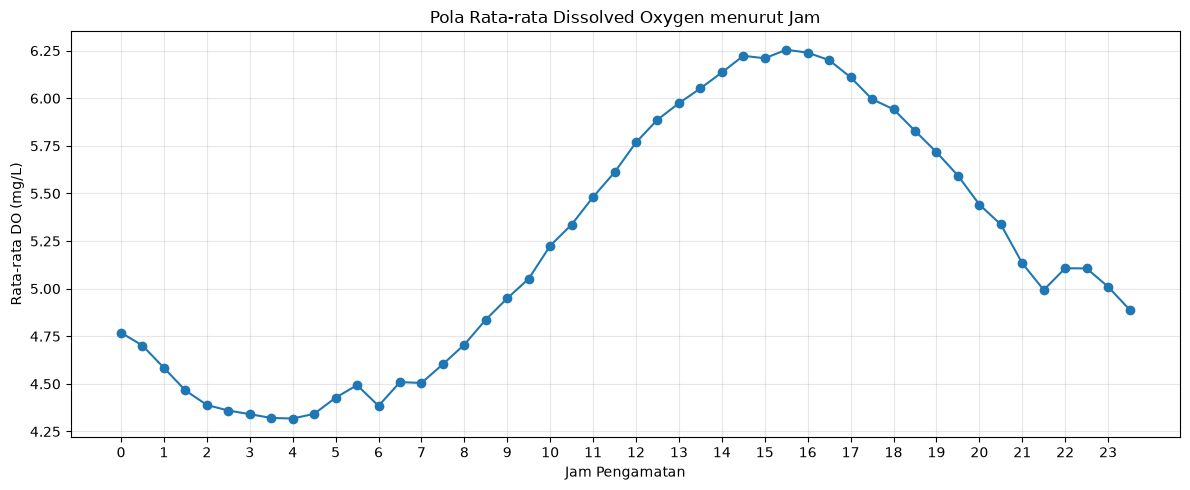

In [31]:
hourly_mean = (
    df.groupby("hour_decimal")[water_quality]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_mean.index,
    hourly_mean["dissolved_oxygen_mg_l"],
    marker="o"
)

plt.xlabel("Jam Pengamatan")
plt.ylabel("Rata-rata DO (mg/L)")
plt.title("Pola Rata-rata Dissolved Oxygen menurut Jam")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fase awal, tengah, dan akhir siklus budidaya.

In [32]:
def cycle_phase(day):
    if day <= 20:
        return "Awal"
    elif day <= 40:
        return "Tengah"
    else:
        return "Akhir"

df["cycle_phase"] = df["day_of_cycle"].apply(cycle_phase)

phase_quality = (
    df.groupby("cycle_phase")[water_quality]
    .mean()
    .reindex(["Awal", "Tengah", "Akhir"])
    .round(3)
)

phase_quality

,temperature_c,ph,dissolved_oxygen_mg_l,ammonia_mg_l,nitrite_mg_l,turbidity_ntu
cycle_phase,,,,,,
Awal,28.778,7.358,5.344,0.269,0.218,43.350
Tengah,28.627,7.349,5.225,0.337,0.278,49.026
Akhir,28.399,7.354,5.048,0.404,0.346,55.653


### 4. Hitung frekuensi kondisi berisiko pada waktu pengamatan menggunakan ambang DO, amonia, dan nitrit yang diberikan. Sajikan proporsi menurut kolam dan jam.

- DO < 3,5 mg/L
- ammonia > 0,55 mg/L
- nitrite > 0,35 mg/L

In [33]:
df["risk_condition"] = (
    (df["dissolved_oxygen_mg_l"] < 3.5) |
    (df["ammonia_mg_l"] > 0.55) |
    (df["nitrite_mg_l"] > 0.35)
)

df["risk_condition"].value_counts()

risk_condition
False    18191
True      4849
Name: count, dtype: int64

In [34]:
risk_summary = (
    df["risk_condition"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
)

risk_summary

risk_condition
False    78.953993
True     21.046007
Name: percentage, dtype: float64

Resiko menurut kolam

In [35]:
risk_by_pond = (
    df.groupby("pond_id")["risk_condition"]
    .agg(
        risk_count="sum",
        risk_rate="mean"
    )
)

risk_by_pond["risk_pct"] = risk_by_pond["risk_rate"] * 100

risk_by_pond[
    ["risk_count", "risk_pct"]
].round(3)

,risk_count,risk_pct
pond_id,,
P01,4,0.139
P02,172,5.972
P03,1132,39.306
P04,571,19.826
P05,382,13.264
P06,1590,55.208
P07,16,0.556
P08,982,34.097


Resiko menurut jam

In [36]:
risk_by_hour = (
    df.groupby("hour_decimal")["risk_condition"]
    .mean()
    .mul(100)
)

risk_by_hour.round(2)

hour_decimal
0.0     21.04
0.5     20.83
1.0     21.04
1.5     22.50
2.0     20.83
2.5     21.04
3.0     22.50
3.5     22.92
4.0     22.08
4.5     21.46
5.0     21.46
5.5     22.50
6.0     21.25
6.5     20.83
7.0     21.67
7.5     20.42
8.0     21.67
8.5     20.42
9.0     21.04
9.5     21.67
10.0    19.58
10.5    19.79
11.0    20.00
11.5    19.38
12.0    19.17
12.5    19.79
13.0    20.00
13.5    19.58
14.0    20.21
14.5    19.79
15.0    20.21
15.5    20.21
16.0    19.79
16.5    21.04
17.0    21.46
17.5    20.00
18.0    20.00
18.5    21.67
19.0    21.46
19.5    21.25
20.0    22.71
20.5    21.46
21.0    21.67
21.5    21.88
22.0    22.29
22.5    22.50
23.0    22.29
23.5    21.88
Name: risk_condition, dtype: float64

visualisasi kolam x jam

In [37]:
import seaborn as sns

risk_heatmap = (
    df.groupby(["pond_id", "hour_decimal"])["risk_condition"]
    .mean()
    .unstack()
    * 100
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    risk_heatmap,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Proporsi Kondisi Berisiko menurut Kolam dan Jam")
plt.xlabel("Jam")
plt.ylabel("Kolam")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

fish stress event

In [ ]:
stress_summary = (
    df["fish_stress_event"]
    .value_counts()
    .sort_index()
)

stress_summary

Stress menurut kolam

In [ ]:
stress_by_pond = (
    df.groupby("pond_id")["fish_stress_event"]
    .agg(
        stress_count="sum",
        stress_rate="mean"
    )
)

stress_by_pond["stress_pct"] = stress_by_pond["stress_rate"] * 100

stress_by_pond[
    ["stress_count", "stress_pct"]
].round(3)

stress menurut jam

In [ ]:
stress_by_hour = (
    df.groupby("hour_decimal")["fish_stress_event"]
    .mean()
    .mul(100)
)

stress_by_hour.round(3)

jam dengan event terbanyak

In [ ]:
stress_by_hour.sort_values(ascending=False).head(10)

grafik distribusi

In [ ]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, col in zip(axes.flat, water_quality):

    ax.hist(
        df[col].dropna(),
        bins=30
    )

    ax.set_title(col)
    ax.set_xlabel("Nilai")
    ax.set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

Grafik waktu normal dengan waktu terbanyak

In [ ]:
sample = df[
    (df["pond_id"] == "P06") &
    (df["timestamp"].between(
        "2026-02-01",
        "2026-02-03"
    ))
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    sample["timestamp"],
    sample["dissolved_oxygen_mg_l"],
    label="DO"
)

risk_sample = sample[
    sample["dissolved_oxygen_mg_l"] < 3.5
]

plt.scatter(
    risk_sample["timestamp"],
    risk_sample["dissolved_oxygen_mg_l"],
    label="DO < 3.5 mg/L"
)

plt.axhline(
    3.5,
    linestyle="--",
    label="Batas risiko DO"
)

plt.xlabel("Waktu")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.title("Contoh Perubahan DO dan Kondisi Ekstrem pada P06")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##**4.3 C. Diagnotic Analytics: Mengapa Terjadi**

1. Risiko antar-kolam

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

In [ ]:
# Ringkasan risiko tiap kolam

risk_by_pond = (
    df.groupby("pond_id")
    .agg(
        total_observation=("record_id","count"),
        risk_count=("risk_next_3h","sum"),
        risk_rate=("risk_next_3h","mean"),
        avg_biomass=("biomass_kg","mean"),
        avg_density=("stocking_density_kg_m3","mean"),
        avg_temperature=("temperature_c","mean")
    )
    .reset_index()
)

risk_by_pond["risk_rate"] = risk_by_pond["risk_rate"]*100

risk_by_pond

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_by_pond,
    x="pond_id",
    y="risk_rate"
)

plt.ylabel("Risk Rate (%)")
plt.xlabel("Pond")
plt.title("Risk Rate Comparison Between Ponds")

plt.show()

2. Aerator dan Oksigen Terlarut

In [ ]:
df.groupby("aerator_status")[
    "dissolved_oxygen_mg_l"
].agg(
    ["count","mean","median","std"]
)

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="aerator_status",
    y="dissolved_oxygen_mg_l"
)

plt.title("Dissolved Oxygen Distribution by Aerator Status")
plt.xlabel("Aerator Status")
plt.ylabel("DO (mg/L)")

plt.show()

Stratifikasi berdasarkan kolam

In [ ]:
do_aerator_pond = (
    df.groupby(
        ["pond_id","aerator_status"]
    )
    ["dissolved_oxygen_mg_l"]
    .mean()
    .reset_index()
)

do_aerator_pond

3. Gangguan aerator

In [ ]:
do_aerator_pond = (
    df.groupby(
        ["pond_id","aerator_status"]
    )
    ["dissolved_oxygen_mg_l"]
    .mean()
    .reset_index()
)

do_aerator_pond

Analisis Gangguan Aerator

In [ ]:
df = df.sort_values(
    ["pond_id","timestamp"]
)


df["aerator_fault_event"] = (
    df["aerator_fault"]
    != df["aerator_fault"].shift(1)
)


fault_time = df[
    df["aerator_fault_event"]
][
    [
        "pond_id",
        "timestamp"
    ]
]


fault_time.head()

In [ ]:
fault_effect=[]


for _,row in fault_time.iterrows():

    pond=row["pond_id"]
    time=row["timestamp"]

    temp=df[
        (df.pond_id==pond)
        &
        (df.timestamp.between(
            time-pd.Timedelta(hours=3),
            time+pd.Timedelta(hours=3)
        ))
    ].copy()

    temp["relative_hour"] = (
        (temp.timestamp-time)
        /
        pd.Timedelta(hours=1)
    )

    fault_effect.append(temp)


fault_analysis = pd.concat(
    fault_effect,
    ignore_index=True
)

fault_analysis.head()

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=fault_analysis,
    x="relative_hour",
    y="dissolved_oxygen_mg_l",
    errorbar=None
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "DO Change Around Aerator Fault Event"
)

plt.xlabel(
    "Relative Time (Hour)"
)

plt.ylabel(
    "Dissolved Oxygen (mg/L)"
)

plt.show()

4. Efek Tertunda pakan

In [ ]:
df=df.sort_values(
    ["pond_id","timestamp"]
)


for i in range(1,13):

    df[f"feed_lag_{i}"] = (
        df.groupby("pond_id")
        ["feed_kg"]
        .shift(i)
    )

In [ ]:
lag_result=[]


for i in range(1,13):

    lag_result.append(
        {
            "lag":i,
            "ammonia_corr":
            df[f"feed_lag_{i}"].corr(
                df["ammonia_mg_l"]
            ),

            "nitrite_corr":
            df[f"feed_lag_{i}"].corr(
                df["nitrite_mg_l"]
            ),

            "DO_corr":
            df[f"feed_lag_{i}"].corr(
                df["dissolved_oxygen_mg_l"]
            )
        }
    )


lag_result=pd.DataFrame(lag_result)

lag_result

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=lag_result,
    x="lag",
    y="ammonia_corr",
    marker="o"
)

plt.title(
    "Feed Lag Effect on Ammonia"
)

plt.xlabel(
    "Lag Interval (30 minutes)"
)

plt.ylabel(
    "Correlation"
)

plt.show()

5. Hujan

In [ ]:
#Kategori Hujan
df["rain_category"] = pd.cut(
    df["rainfall_mm"],
    bins=[
        -1,
        0,
        10,
        np.inf
    ],
    labels=[
        "No Rain",
        "Light Rain",
        "Heavy Rain"
    ]
)

In [ ]:
rain_analysis = (
    df.groupby("rain_category")
    [
        [
            "dissolved_oxygen_mg_l",
            "ammonia_mg_l",
            "nitrite_mg_l"
        ]
    ]
    .mean()
)

rain_analysis

6. Pertukaran air

In [ ]:
df["water_exchange_event"] = (
    df["water_exchange_pct"]>0
)


water_exchange_result = (
    df.groupby(
        "water_exchange_event"
    )
    [
        [
            "ammonia_mg_l",
            "nitrite_mg_l"
        ]
    ]
    .mean()pip install opencv-python

)


water_exchange_result